In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
plt.style.use('ggplot')
pd.set_option('display.max_columns', 200) # to see all output of spreadsheet

# Original Dataset
These datasets consist of basketball statistics from NBA, BAA, and ABA leagues. "Team Stats Per Game.csv" measures offensive skills and "Opponent Stats Per Game.csv" measures defensive skills. Both measure per-game averages for a team over a season.

## Labels from "Team Stats Per Game.csv"
season : year the season took place (Possible Values: 1947-2026) (Ex. 2026 refers to the current 2025-2026 season)\
lg : league/association (Possible Values: NBA, ABA, BAA)\
team : full team name (Possible Values: 97 unique team names) (1)(2)\
abbreviation : abbreviated version of team name\
playoffs : boolean value indicating whether the team made it to the post-season tournaments (3)(4)\
g : total games played by the team in the season (5)\
mp_per_game : minutes played per game (240 is usually the standard)\
fg_per_game : field goals made per game\
fga_per_game : field goal attempts per game\
fg_percent : field goal percentage (accuracy)\
x3p_per_game : 3-pointers made per game\
x3pa_per_game : 3-pointer attempts per game\
x3p_percent : 3-point shooting percentage (accuracy)\
x2p_per_game : 2-pointers made\
x2pa_per_game : 2-pointer attempts\
x2p_percent : 2-point shooting percentage (accuracy)\
ft_per_game : free throws made\
fta_per_game : free throw attempts\
ft_percent : free throw percentage (accuracy)\
orb_per_game : offensive rebounds\
drb_per_game : defensive rebounds\
trb_per_game : total rebounds\
ast_per_game : assists\
stl_per_game : steals\
blk_per_game : blocks\
tov_per_game : turnovers\
pf_per_game : personal fouls\
pts_per_game : total points scored per game

## Labels from "Opponent Stats Per Game.csv"
"Opponent Stats Per Game.csv" includes the same labels but with "opp_" added to the beginning to indicate opponent statistics.

## Footnotes
(1) Since this dataset spans from 1947-2026, this includes all defunct teams, and teams who have since changed their names. There are currently only 30 active NBA teams.\
(2) This label also includes a value "Team League" for the average statistics for all teams for the entire season\
(3) This includes teams who made it to the Play-In Tournaments, which is why there are 20 teams marked as TRUE per season for this label, when the official playoffs are usually only 16 teams.\
(4) Since the 2026 season is ongoing, 'playoffs' is automatically marked FALSE for all teams\
(5) Usually each team plays 82 games, however there are outliers. (During COVID, many games were dropped. Also the NBA has had 'lockout" seasons where they ended early due to union disagreements).



In [2]:
#Cell to import from Google Drive if on Colab
#If running locally, don't run this cell
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [115]:
from pandas.core.reshape import merge
team_df = pd.read_csv('https://raw.githubusercontent.com/sumitrodatta/bball-reference-datasets/refs/heads/master/Data/Team%20Stats%20Per%20Game.csv')
opp_df = pd.read_csv('https://raw.githubusercontent.com/sumitrodatta/bball-reference-datasets/refs/heads/master/Data/Opponent%20Stats%20Per%20Game.csv')

# merging the datasets
common_columns = ['season', 'lg', 'team', 'abbreviation', 'playoffs', 'g', 'mp_per_game']
merged_df = pd.merge(team_df, opp_df, on=common_columns)

#Transform into net values rather than having team and opp values
#I know there's a more efficient way to do this but I hate python syntax shenanigans so take this hardcoded blob
merged_df['net_fg_per_game'] = merged_df['fg_per_game'] - merged_df['opp_fg_per_game']
merged_df['net_fga_per_game'] = merged_df['fga_per_game'] - merged_df['opp_fga_per_game']
merged_df['net_fg_percent'] = merged_df['fg_percent'] - merged_df['opp_fg_percent']
merged_df['net_x3p_per_game'] = merged_df['x3p_per_game'] - merged_df['opp_x3p_per_game']
merged_df['net_x3pa_per_game'] = merged_df['x3pa_per_game'] - merged_df['opp_x3pa_per_game']
merged_df['net_x3p_percent'] = merged_df['x3p_percent'] - merged_df['opp_x3p_percent']
merged_df['net_x2p_per_game'] = merged_df['x2p_per_game'] - merged_df['opp_x2p_per_game']
merged_df['net_x2pa_per_game'] = merged_df['x2pa_per_game'] - merged_df['opp_x2pa_per_game']
merged_df['net_x2p_percent'] = merged_df['x2p_percent'] - merged_df['opp_x2p_percent']
merged_df['net_ft_per_game'] = merged_df['ft_per_game'] - merged_df['opp_ft_per_game']
merged_df['net_fta_per_game'] = merged_df['fta_per_game'] - merged_df['opp_fta_per_game']
merged_df['net_ft_percent'] = merged_df['ft_percent'] - merged_df['opp_ft_percent']
merged_df['net_orb_per_game'] = merged_df['orb_per_game'] - merged_df['opp_orb_per_game']
merged_df['net_drb_per_game'] = merged_df['drb_per_game'] - merged_df['opp_drb_per_game']
merged_df['net_trb_per_game'] = merged_df['trb_per_game'] - merged_df['opp_trb_per_game']
merged_df['net_ast_per_game'] = merged_df['ast_per_game'] - merged_df['opp_ast_per_game']
merged_df['net_stl_per_game'] = merged_df['stl_per_game'] - merged_df['opp_stl_per_game']
merged_df['net_blk_per_game'] = merged_df['blk_per_game'] - merged_df['opp_blk_per_game']
merged_df['net_tov_per_game'] = merged_df['tov_per_game'] - merged_df['opp_tov_per_game']
merged_df['net_pf_per_game'] = merged_df['pf_per_game'] - merged_df['opp_pf_per_game']

cols_to_drop = merged_df.loc[:, 'fg_per_game':'pf_per_game'].columns
merged_df = merged_df.drop(columns=cols_to_drop)
cols_to_drop = merged_df.loc[:, 'opp_fg_per_game':'opp_pf_per_game'].columns
merged_df = merged_df.drop(columns=cols_to_drop)

# add column for point differential
merged_df['point_diff'] = merged_df['pts_per_game'] - merged_df['opp_pts_per_game']

#These should probably be dropped as well, since point_diff is our actual dependent variable. I'm only commenting this so that I remember that I removed them
cols_to_drop = merged_df.loc[:, 'pts_per_game':'opp_pts_per_game'].columns
merged_df = merged_df.drop(columns=cols_to_drop)

# save into new .csv file
merged_df.to_csv('Full_Basketball_Stats.csv', index=False)



In [116]:
merged_df.shape

(1907, 28)

In [117]:
merged_df.head()

,season,lg,team,abbreviation,playoffs,g,mp_per_game,net_fg_per_game,net_fga_per_game,net_fg_percent,net_x3p_per_game,net_x3pa_per_game,net_x3p_percent,net_x2p_per_game,net_x2pa_per_game,net_x2p_percent,net_ft_per_game,net_fta_per_game,net_ft_percent,net_orb_per_game,net_drb_per_game,net_trb_per_game,net_ast_per_game,net_stl_per_game,net_blk_per_game,net_tov_per_game,net_pf_per_game,point_diff
0,2026,NBA,Atlanta Hawks,ATL,False,51.0,241.0,0.2,1.2,-0.004,1.3,2.0,0.016,-1.1,-0.8,-0.012,-2.9,-3.0,-0.023,-1.7,-2.8,-4.5,3.3,0.5,-0.3,-1.5,1.7,-1.1
1,2026,NBA,Boston Celtics,BOS,False,48.0,241.0,4.2,4.6,0.023,1.3,3.2,0.005,2.8,1.4,0.044,-3.1,-3.8,-0.003,1.1,1.5,2.6,-1.7,1.9,0.9,-1.6,1.4,6.6
2,2026,NBA,Brooklyn Nets,BRK,False,47.0,241.6,-4.3,-0.6,-0.047,1.4,7.6,-0.037,-5.7,-8.2,-0.025,0.5,0.8,-0.004,0.7,-3.5,-2.8,-2.2,-0.9,-0.4,1.4,0.1,-6.7
3,2026,NBA,Chicago Bulls,CHI,False,49.0,241.0,-0.8,-2.5,0.004,0.9,2.0,0.006,-1.7,-4.4,0.013,-1.2,-1.7,0.002,-0.8,1.2,0.5,2.2,-1.4,-0.4,1.9,0.2,-1.9
4,2026,NBA,Charlotte Hornets,CHO,False,50.0,241.5,-1.2,-0.7,-0.010,2.0,4.7,0.006,-3.2,-5.4,-0.006,2.2,2.5,0.010,1.8,4.2,6.1,-0.6,-1.7,0.1,3.1,-1.4,1.6


In [6]:
merged_df.tail()

,season,lg,team,abbreviation,playoffs,g,mp_per_game,fg_per_game,fga_per_game,fg_percent,x3p_per_game,x3pa_per_game,x3p_percent,x2p_per_game,x2pa_per_game,x2p_percent,ft_per_game,fta_per_game,ft_percent,orb_per_game,drb_per_game,trb_per_game,ast_per_game,stl_per_game,blk_per_game,tov_per_game,pf_per_game,pts_per_game,opp_fg_per_game,opp_fga_per_game,opp_fg_percent,opp_x3p_per_game,opp_x3pa_per_game,opp_x3p_percent,opp_x2p_per_game,opp_x2pa_per_game,opp_x2p_percent,opp_ft_per_game,opp_fta_per_game,opp_ft_percent,opp_orb_per_game,opp_drb_per_game,opp_trb_per_game,opp_ast_per_game,opp_stl_per_game,opp_blk_per_game,opp_tov_per_game,opp_pf_per_game,opp_pts_per_game,point_diff
1902,1947,BAA,Providence Steamrollers,PRO,False,60.0,NaN,27.2,93.0,0.292,NaN,NaN,NaN,27.2,93.0,0.292,18.2,27.8,0.655,NaN,NaN,NaN,8.0,NaN,NaN,NaN,20.3,72.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,74.2,-1.7
1903,1947,BAA,St. Louis Bombers,STB,True,61.0,NaN,26.2,96.3,0.272,NaN,NaN,NaN,26.2,96.3,0.272,14.1,23.0,0.616,NaN,NaN,NaN,4.8,NaN,NaN,NaN,20.2,66.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.1,2.5
1904,1947,BAA,Toronto Huskies,TRH,False,60.0,NaN,25.3,94.5,0.267,NaN,NaN,NaN,25.3,94.5,0.267,16.1,25.9,0.622,NaN,NaN,NaN,7.7,NaN,NaN,NaN,21.2,66.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,71.0,-4.4
1905,1947,BAA,Washington Capitols,WSC,True,60.0,NaN,28.7,96.6,0.297,NaN,NaN,NaN,28.7,96.6,0.297,16.4,23.2,0.706,NaN,NaN,NaN,6.3,NaN,NaN,NaN,19.1,73.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,63.9,9.9
1906,1947,BAA,League Average,NaN,False,60.0,NaN,25.9,92.9,0.279,NaN,NaN,NaN,25.9,92.9,0.279,15.9,24.8,0.641,NaN,NaN,NaN,6.9,NaN,NaN,NaN,20.8,67.8,25.9,92.9,0.279,NaN,NaN,NaN,25.9,92.9,0.279,15.9,24.8,0.641,NaN,NaN,NaN,6.9,NaN,NaN,NaN,20.8,67.8,0.0


In [7]:
merged_df.columns

Index(['season', 'lg', 'team', 'abbreviation', 'playoffs', 'g', 'mp_per_game',
       'fg_per_game', 'fga_per_game', 'fg_percent', 'x3p_per_game',
       'x3pa_per_game', 'x3p_percent', 'x2p_per_game', 'x2pa_per_game',
       'x2p_percent', 'ft_per_game', 'fta_per_game', 'ft_percent',
       'orb_per_game', 'drb_per_game', 'trb_per_game', 'ast_per_game',
       'stl_per_game', 'blk_per_game', 'tov_per_game', 'pf_per_game',
       'pts_per_game', 'opp_fg_per_game', 'opp_fga_per_game', 'opp_fg_percent',
       'opp_x3p_per_game', 'opp_x3pa_per_game', 'opp_x3p_percent',
       'opp_x2p_per_game', 'opp_x2pa_per_game', 'opp_x2p_percent',
       'opp_ft_per_game', 'opp_fta_per_game', 'opp_ft_percent',
       'opp_orb_per_game', 'opp_drb_per_game', 'opp_trb_per_game',
       'opp_ast_per_game', 'opp_stl_per_game', 'opp_blk_per_game',
       'opp_tov_per_game', 'opp_pf_per_game', 'opp_pts_per_game',
       'point_diff'],
      dtype='object')

In [71]:
merged_df.dtypes

,0
season,int64
lg,object
team,object
abbreviation,object
playoffs,bool
g,float64
mp_per_game,float64
pts_per_game,float64
opp_pts_per_game,float64
net_fg_per_game,float64


In [72]:
merged_df.describe()

,season,g,mp_per_game,pts_per_game,opp_pts_per_game,net_fg_per_game,net_fga_per_game,net_fg_percent,net_x3p_per_game,net_x3pa_per_game,net_x3p_percent,net_x2p_per_game,net_x2pa_per_game,net_x2p_percent,net_ft_per_game,net_fta_per_game,net_ft_percent,net_orb_per_game,net_drb_per_game,net_trb_per_game,net_ast_per_game,net_stl_per_game,net_blk_per_game,net_tov_per_game,net_pf_per_game,point_diff
count,1907.000000,1906.000000,1717.000000,1906.000000,1906.000000,1669.000000,1667.000000,1666.000000,1464.000000,1464.000000,1464.000000,1669.000000,1667.00000,1667.000000,1669.000000,1668.000000,1667.000000,1544.000000,1544.000000,1663.000000,1667.000000,1519.000000,1519.000000,1647.000000,1669.000000,1906.000000
mean,1993.349240,79.028856,241.609552,103.974921,103.980063,-0.003595,0.000420,0.000071,-0.000342,0.001298,-0.003645,-0.002097,0.00090,0.000231,-0.000899,-0.001319,0.000194,0.002202,-0.000324,0.001143,-0.004379,-0.002502,0.000461,0.000304,0.002337,-0.005142
std,20.982797,7.823157,0.830039,9.773447,9.789420,1.923052,2.865499,0.023007,1.343059,3.272448,0.036471,2.218137,4.19966,0.025867,2.401557,2.977727,0.028012,1.501024,2.106216,2.738526,2.332169,1.075598,1.127045,1.544879,1.672711,4.468265
min,1947.000000,11.000000,237.700000,60.100000,63.900000,-5.900000,-9.100000,-0.073000,-4.100000,-10.900000,-0.228000,-7.200000,-14.90000,-0.084000,-10.000000,-11.000000,-0.115000,-7.000000,-6.500000,-9.700000,-7.000000,-3.300000,-4.300000,-5.300000,-5.700000,-15.200000
25%,1976.500000,82.000000,241.000000,97.900000,98.025000,-1.200000,-1.700000,-0.015000,-0.700000,-1.800000,-0.022000,-1.400000,-2.60000,-0.017000,-1.500000,-2.000000,-0.017000,-1.000000,-1.400000,-1.800000,-1.600000,-0.700000,-0.700000,-1.000000,-1.100000,-2.900000
50%,1995.000000,82.000000,241.500000,104.900000,105.100000,0.000000,0.000000,0.000000,0.000000,-0.100000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2011.000000,82.000000,242.100000,111.075000,111.075000,1.300000,1.800000,0.015000,0.700000,1.800000,0.017000,1.500000,2.75000,0.016000,1.500000,2.000000,0.019000,1.000000,1.500000,1.800000,1.500000,0.700000,0.700000,1.000000,1.100000,3.100000
max,2026.000000,84.000000,244.900000,126.500000,130.800000,6.700000,11.700000,0.085000,6.000000,15.600000,0.150000,7.900000,14.90000,0.110000,7.800000,10.500000,0.102000,5.700000,6.700000,11.800000,7.700000,4.400000,3.800000,5.500000,5.900000,12.900000


In [73]:
unique_teams = sorted(merged_df['team'].unique())
print(f"There are {len(unique_teams)} unique team labels:\n")
for team in unique_teams:
    print(team)

There are 97 unique team labels:

Anaheim Amigos
Anderson Packers
Atlanta Hawks
Baltimore Bullets
Boston Celtics
Brooklyn Nets
Buffalo Braves
Capital Bullets
Carolina Cougars
Charlotte Bobcats
Charlotte Hornets
Chicago Bulls
Chicago Packers
Chicago Stags
Chicago Zephyrs
Cincinnati Royals
Cleveland Cavaliers
Cleveland Rebels
Dallas Chaparrals
Dallas Mavericks
Denver Nuggets
Denver Rockets
Detroit Falcons
Detroit Pistons
Fort Wayne Pistons
Golden State Warriors
Houston Mavericks
Houston Rockets
Indiana Pacers
Indianapolis Jets
Indianapolis Olympians
Kansas City Kings
Kansas City-Omaha Kings
Kentucky Colonels
League Average
Los Angeles Clippers
Los Angeles Lakers
Los Angeles Stars
Memphis Grizzlies
Memphis Pros
Memphis Sounds
Memphis Tams
Miami Floridians
Miami Heat
Milwaukee Bucks
Milwaukee Hawks
Minneapolis Lakers
Minnesota Muskies
Minnesota Pipers
Minnesota Timberwolves
New Jersey Americans
New Jersey Nets
New Orleans Buccaneers
New Orleans Hornets
New Orleans Jazz
New Orleans Pelicans

# Cleaning the Dataset
- only include NBA games
- remove "League Average" statistics, since this information is already in the dataset
- only include the years 1980 - present (Since many statistics like 3 pointers weren't introduced until the 1980s)
- check for duplicates
- check for NaN values
- deal with name changes for teams over the years

In [74]:
# only keep NBA games
NBA_merged_df = merged_df[merged_df['lg'] == 'NBA']

In [75]:
# remove League Average statistics
NBA_merged_df = NBA_merged_df[NBA_merged_df['team'] != 'League Average']

In [76]:
# only 1980 to present
NBA_merged_df = NBA_merged_df[NBA_merged_df['season'] >= 1980]

In [77]:
# check for duplicate rows
NBA_merged_df.loc[merged_df.duplicated()]

,season,lg,team,abbreviation,playoffs,g,mp_per_game,pts_per_game,opp_pts_per_game,net_fg_per_game,net_fga_per_game,net_fg_percent,net_x3p_per_game,net_x3pa_per_game,net_x3p_percent,net_x2p_per_game,net_x2pa_per_game,net_x2p_percent,net_ft_per_game,net_fta_per_game,net_ft_percent,net_orb_per_game,net_drb_per_game,net_trb_per_game,net_ast_per_game,net_stl_per_game,net_blk_per_game,net_tov_per_game,net_pf_per_game,point_diff


In [78]:
# check for null values
NBA_merged_df.isna().sum()

,0
season,0
lg,0
team,0
abbreviation,0
playoffs,0
g,0
mp_per_game,0
pts_per_game,0
opp_pts_per_game,0
net_fg_per_game,0


In [79]:
unique_NBA_teams = sorted(NBA_merged_df['team'].unique())
print(f"There are {len(unique_NBA_teams)} unique NBA team labels:\n")
for team in unique_NBA_teams:
    print(team)

There are 39 unique NBA team labels:

Atlanta Hawks
Boston Celtics
Brooklyn Nets
Charlotte Bobcats
Charlotte Hornets
Chicago Bulls
Cleveland Cavaliers
Dallas Mavericks
Denver Nuggets
Detroit Pistons
Golden State Warriors
Houston Rockets
Indiana Pacers
Kansas City Kings
Los Angeles Clippers
Los Angeles Lakers
Memphis Grizzlies
Miami Heat
Milwaukee Bucks
Minnesota Timberwolves
New Jersey Nets
New Orleans Hornets
New Orleans Pelicans
New Orleans/Oklahoma City Hornets
New York Knicks
Oklahoma City Thunder
Orlando Magic
Philadelphia 76ers
Phoenix Suns
Portland Trail Blazers
Sacramento Kings
San Antonio Spurs
San Diego Clippers
Seattle SuperSonics
Toronto Raptors
Utah Jazz
Vancouver Grizzlies
Washington Bullets
Washington Wizards


In [80]:
# dealing with name changes
team_mapping = {
    'Seattle SuperSonics': 'Oklahoma City Thunder',
    'New Jersey Nets': 'Brooklyn Nets',
    'Vancouver Grizzlies': 'Memphis Grizzlies',
    'San Diego Clippers': 'Los Angeles Clippers',
    'New Orleans Hornets': 'New Orleans Pelicans',
    'New Orleans/Oklahoma City Hornets': 'New Orleans Pelicans',
    'Charlotte Bobcats': 'Charlotte Hornets',
    'Washington Bullets': 'Washington Wizards',
    'Kansas City Kings': 'Sacramento Kings'
}

NBA_merged_df['team'] = NBA_merged_df['team'].replace(team_mapping)

unique_NBA_teams = sorted(NBA_merged_df['team'].unique())
print(f"There are {len(unique_NBA_teams)} unique NBA team labels:\n")
for team in unique_NBA_teams:
    print(team)

There are 30 unique NBA team labels:

Atlanta Hawks
Boston Celtics
Brooklyn Nets
Charlotte Hornets
Chicago Bulls
Cleveland Cavaliers
Dallas Mavericks
Denver Nuggets
Detroit Pistons
Golden State Warriors
Houston Rockets
Indiana Pacers
Los Angeles Clippers
Los Angeles Lakers
Memphis Grizzlies
Miami Heat
Milwaukee Bucks
Minnesota Timberwolves
New Orleans Pelicans
New York Knicks
Oklahoma City Thunder
Orlando Magic
Philadelphia 76ers
Phoenix Suns
Portland Trail Blazers
Sacramento Kings
San Antonio Spurs
Toronto Raptors
Utah Jazz
Washington Wizards


In [81]:
# fix corresponding abbreviations
unique_NBA_abbr = sorted(NBA_merged_df['abbreviation'].unique())
print(f"There are {len(unique_NBA_abbr)} unique NBA abbreviation labels:\n")
for abbreviation in unique_NBA_abbr:
    print(abbreviation)

There are 40 unique NBA abbreviation labels:

ATL
BOS
BRK
CHA
CHH
CHI
CHO
CLE
DAL
DEN
DET
GSW
HOU
IND
KCK
LAC
LAL
MEM
MIA
MIL
MIN
NJN
NOH
NOK
NOP
NYK
OKC
ORL
PHI
PHO
POR
SAC
SAS
SDC
SEA
TOR
UTA
VAN
WAS
WSB


In [82]:
abbr_mapping = {
    'SEA': 'OKC',
    'NJN': 'BRK',
    'VAN': 'MEM',
    'WSB': 'WAS',
    'KCK': 'SAC',
    'CHH': 'NOP',
    'NOH': 'NOP',
    'NOK': 'NOP',
    'CHA': 'CHO',
    'SDC': 'LAC'
}

NBA_merged_df['abbreviation'] = NBA_merged_df['abbreviation'].replace(abbr_mapping)

In [83]:
# fixing the double abbreviations for the Charlotte Hornets (complicated history)
NBA_merged_df.loc[(NBA_merged_df['team'] == 'Charlotte Hornets') & (NBA_merged_df['abbreviation'] == 'NOP'), 'team'] = 'New Orleans Pelicans'
NBA_merged_df.loc[NBA_merged_df['team'] == 'Charlotte Hornets', 'abbreviation'] = 'CHO'

In [84]:
print(NBA_merged_df[['team', 'abbreviation']].drop_duplicates().sort_values('team'))

                      team abbreviation
0            Atlanta Hawks          ATL
1           Boston Celtics          BOS
2            Brooklyn Nets          BRK
4        Charlotte Hornets          CHO
3            Chicago Bulls          CHI
5      Cleveland Cavaliers          CLE
6         Dallas Mavericks          DAL
7           Denver Nuggets          DEN
8          Detroit Pistons          DET
9    Golden State Warriors          GSW
10         Houston Rockets          HOU
11          Indiana Pacers          IND
12    Los Angeles Clippers          LAC
13      Los Angeles Lakers          LAL
14       Memphis Grizzlies          MEM
15              Miami Heat          MIA
16         Milwaukee Bucks          MIL
17  Minnesota Timberwolves          MIN
18    New Orleans Pelicans          NOP
19         New York Knicks          NYK
20   Oklahoma City Thunder          OKC
21           Orlando Magic          ORL
22      Philadelphia 76ers          PHI
23            Phoenix Suns          PHO


In [85]:
# save the cleaned dataset
NBA_merged_df.to_csv('Cleaned_NBA_Stats.csv', index=False)

# Cleaned Dataset Attributes

In [86]:
NBA_merged_df.shape

(1314, 30)

In [87]:
NBA_merged_df.head()

,season,lg,team,abbreviation,playoffs,g,mp_per_game,pts_per_game,opp_pts_per_game,net_fg_per_game,net_fga_per_game,net_fg_percent,net_x3p_per_game,net_x3pa_per_game,net_x3p_percent,net_x2p_per_game,net_x2pa_per_game,net_x2p_percent,net_ft_per_game,net_fta_per_game,net_ft_percent,net_orb_per_game,net_drb_per_game,net_trb_per_game,net_ast_per_game,net_stl_per_game,net_blk_per_game,net_tov_per_game,net_pf_per_game,point_diff
0,2026,NBA,Atlanta Hawks,ATL,False,51.0,241.0,117.2,118.3,0.2,1.2,-0.004,1.3,2.0,0.016,-1.1,-0.8,-0.012,-2.9,-3.0,-0.023,-1.7,-2.8,-4.5,3.3,0.5,-0.3,-1.5,1.7,-1.1
1,2026,NBA,Boston Celtics,BOS,False,48.0,241.0,116.3,109.7,4.2,4.6,0.023,1.3,3.2,0.005,2.8,1.4,0.044,-3.1,-3.8,-0.003,1.1,1.5,2.6,-1.7,1.9,0.9,-1.6,1.4,6.6
2,2026,NBA,Brooklyn Nets,BRK,False,47.0,241.6,107.7,114.4,-4.3,-0.6,-0.047,1.4,7.6,-0.037,-5.7,-8.2,-0.025,0.5,0.8,-0.004,0.7,-3.5,-2.8,-2.2,-0.9,-0.4,1.4,0.1,-6.7
3,2026,NBA,Chicago Bulls,CHI,False,49.0,241.0,117.8,119.7,-0.8,-2.5,0.004,0.9,2.0,0.006,-1.7,-4.4,0.013,-1.2,-1.7,0.002,-0.8,1.2,0.5,2.2,-1.4,-0.4,1.9,0.2,-1.9
4,2026,NBA,Charlotte Hornets,CHO,False,50.0,241.5,116.2,114.6,-1.2,-0.7,-0.010,2.0,4.7,0.006,-3.2,-5.4,-0.006,2.2,2.5,0.010,1.8,4.2,6.1,-0.6,-1.7,0.1,3.1,-1.4,1.6


In [88]:
NBA_merged_df.tail()

,season,lg,team,abbreviation,playoffs,g,mp_per_game,pts_per_game,opp_pts_per_game,net_fg_per_game,net_fga_per_game,net_fg_percent,net_x3p_per_game,net_x3pa_per_game,net_x3p_percent,net_x2p_per_game,net_x2pa_per_game,net_x2p_percent,net_ft_per_game,net_fta_per_game,net_ft_percent,net_orb_per_game,net_drb_per_game,net_trb_per_game,net_ast_per_game,net_stl_per_game,net_blk_per_game,net_tov_per_game,net_pf_per_game,point_diff
1355,1980,NBA,San Antonio Spurs,SAS,True,82.0,240.9,119.4,119.7,-1.8,-3.1,-0.002,-0.5,-1.0,-0.054,-1.3,-2.1,-0.002,3.6,3.0,0.043,-1.1,0.6,-0.7,-2.5,-0.7,-1.5,0.9,-1.1,-0.3
1356,1980,NBA,Los Angeles Clippers,LAC,False,82.0,240.9,107.6,111.7,-2.8,-0.2,-0.030,1.7,4.3,0.096,-4.4,-4.5,-0.025,-0.2,1.0,-0.037,0.9,-2.2,-1.3,-3.9,-1.2,-1.5,0.6,0.1,-4.1
1357,1980,NBA,Oklahoma City Thunder,OKC,True,82.0,241.8,108.5,103.8,1.7,1.8,0.011,0.0,-0.6,0.066,1.8,2.4,0.008,1.1,1.3,0.004,2.1,1.7,3.9,0.3,0.2,0.4,-0.3,-1.7,4.7
1358,1980,NBA,Utah Jazz,UTA,False,82.0,241.5,102.4,108.4,-2.2,-4.5,0.000,-0.1,-0.3,0.001,-2.1,-4.1,0.000,-1.6,-3.2,0.037,-2.3,0.9,-1.4,0.1,-0.7,-0.5,3.3,2.8,-6.0
1359,1980,NBA,Washington Wizards,WAS,True,82.0,242.4,107.0,109.5,-0.5,0.3,-0.007,0.2,0.3,0.045,-0.7,0.0,-0.008,-1.8,-1.6,-0.019,1.7,0.6,2.3,0.9,-2.5,-0.9,1.9,-0.1,-2.5


In [89]:
NBA_merged_df.columns

Index(['season', 'lg', 'team', 'abbreviation', 'playoffs', 'g', 'mp_per_game',
       'pts_per_game', 'opp_pts_per_game', 'net_fg_per_game',
       'net_fga_per_game', 'net_fg_percent', 'net_x3p_per_game',
       'net_x3pa_per_game', 'net_x3p_percent', 'net_x2p_per_game',
       'net_x2pa_per_game', 'net_x2p_percent', 'net_ft_per_game',
       'net_fta_per_game', 'net_ft_percent', 'net_orb_per_game',
       'net_drb_per_game', 'net_trb_per_game', 'net_ast_per_game',
       'net_stl_per_game', 'net_blk_per_game', 'net_tov_per_game',
       'net_pf_per_game', 'point_diff'],
      dtype='object')

In [90]:
NBA_merged_df.dtypes

,0
season,int64
lg,object
team,object
abbreviation,object
playoffs,bool
g,float64
mp_per_game,float64
pts_per_game,float64
opp_pts_per_game,float64
net_fg_per_game,float64


In [91]:
NBA_merged_df.describe()

,season,g,mp_per_game,pts_per_game,opp_pts_per_game,net_fg_per_game,net_fga_per_game,net_fg_percent,net_x3p_per_game,net_x3pa_per_game,net_x3p_percent,net_x2p_per_game,net_x2pa_per_game,net_x2p_percent,net_ft_per_game,net_fta_per_game,net_ft_percent,net_orb_per_game,net_drb_per_game,net_trb_per_game,net_ast_per_game,net_stl_per_game,net_blk_per_game,net_tov_per_game,net_pf_per_game,point_diff
count,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000
mean,2004.146119,79.675799,241.668721,103.735616,103.738052,-0.002740,-0.000304,0.000089,-0.000076,0.001446,-0.003167,-0.000228,0.000076,0.000304,-0.001142,-0.000076,0.000185,0.001218,-0.000228,-0.000761,-0.001446,-0.001826,0.000685,0.002740,0.001218,-0.002435
std,13.260066,7.354679,0.840060,7.826890,7.865765,1.972965,2.794786,0.023883,1.395169,3.372690,0.036063,2.299218,4.407329,0.027418,2.413687,2.989582,0.029159,1.498686,2.133005,2.723478,2.417042,1.074504,1.144179,1.522042,1.707231,4.699213
min,1980.000000,46.000000,240.000000,81.900000,83.400000,-5.900000,-8.300000,-0.073000,-4.100000,-10.900000,-0.228000,-7.200000,-14.900000,-0.084000,-10.000000,-11.000000,-0.115000,-7.000000,-6.500000,-9.700000,-7.000000,-3.300000,-4.300000,-5.300000,-5.700000,-15.200000
25%,1993.000000,82.000000,241.200000,97.500000,97.600000,-1.300000,-1.800000,-0.017000,-0.800000,-1.900000,-0.021000,-1.500000,-2.800000,-0.019000,-1.500000,-2.000000,-0.019000,-1.000000,-1.500000,-1.900000,-1.675000,-0.700000,-0.775000,-1.000000,-1.100000,-3.200000
50%,2005.000000,82.000000,241.500000,103.400000,103.800000,0.000000,-0.100000,0.000000,-0.100000,-0.200000,-0.001000,0.000000,0.200000,0.000000,0.000000,0.000000,0.001500,0.000000,0.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.100000,0.300000
75%,2016.000000,82.000000,242.100000,109.975000,109.500000,1.400000,1.800000,0.016000,0.800000,1.900000,0.018000,1.600000,2.900000,0.019000,1.600000,2.100000,0.020750,1.000000,1.500000,1.900000,1.600000,0.700000,0.800000,1.000000,1.100000,3.400000
max,2026.000000,82.000000,244.900000,126.500000,130.800000,6.700000,11.700000,0.066000,6.000000,15.600000,0.150000,7.900000,14.900000,0.110000,7.800000,9.400000,0.102000,5.700000,6.700000,9.800000,7.700000,4.400000,3.800000,5.400000,5.900000,12.900000


# Feature Analysis

In [92]:
# split the data between 3 eras
# 1980s to 2000s
era_80_00 = NBA_merged_df[(NBA_merged_df['season'] >= 1980) & (NBA_merged_df['season'] < 2000)]

# 2000s to 2020s
era_00_20 = NBA_merged_df[(NBA_merged_df['season'] >= 2000) & (NBA_merged_df['season'] < 2020)]

# 2020s to present
era_20_26 = NBA_merged_df[NBA_merged_df['season'] >= 2020]

print(f"1980-2000 rows: {len(era_80_00)}")
print(f"2000-2020 rows: {len(era_00_20)}")
print(f"2020-2026 rows: {len(era_20_26)}")

1980-2000 rows: 509
2000-2020 rows: 595
2020-2026 rows: 210


## Target Variable Distribution (point_diff)
Throughout all eras, the distribution of point_diff is Normal.

### 1980s to 2000s

In [93]:
skew_value = era_80_00['point_diff'].skew()
print(f"Skewness of Point Differential: {skew_value}")

Skewness of Point Differential: -0.24592701919475762


Text(0, 0.5, 'Count')

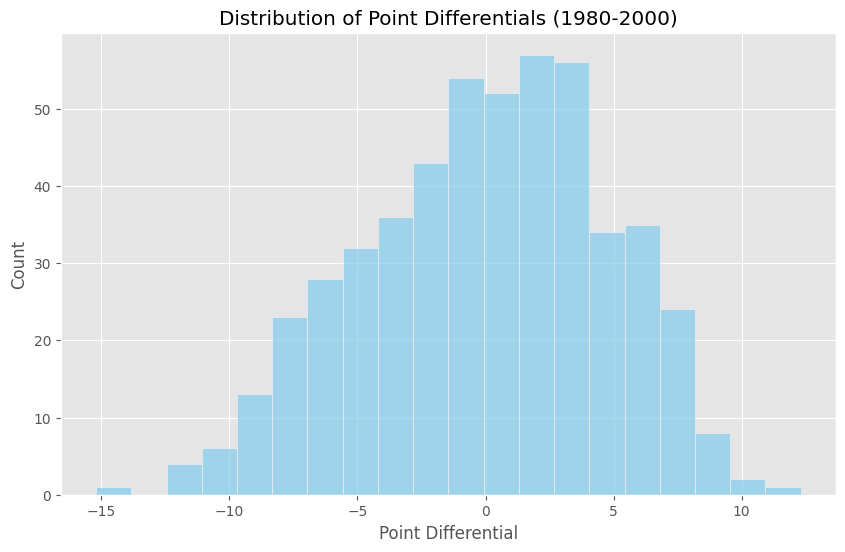

In [94]:
# show the target variable distribution for the dataset
plt.figure(figsize=(10, 6))
sns.histplot(data=era_80_00, x='point_diff', bins=20, color='skyblue')
plt.title('Distribution of Point Differentials (1980-2000)')
plt.xlabel('Point Differential')
plt.ylabel('Count')

### 2000s to 2020s

In [95]:
skew_value = era_00_20['point_diff'].skew()
print(f"Skewness of Point Differential: {skew_value}")

Skewness of Point Differential: -0.17799662886853812


Text(0, 0.5, 'Count')

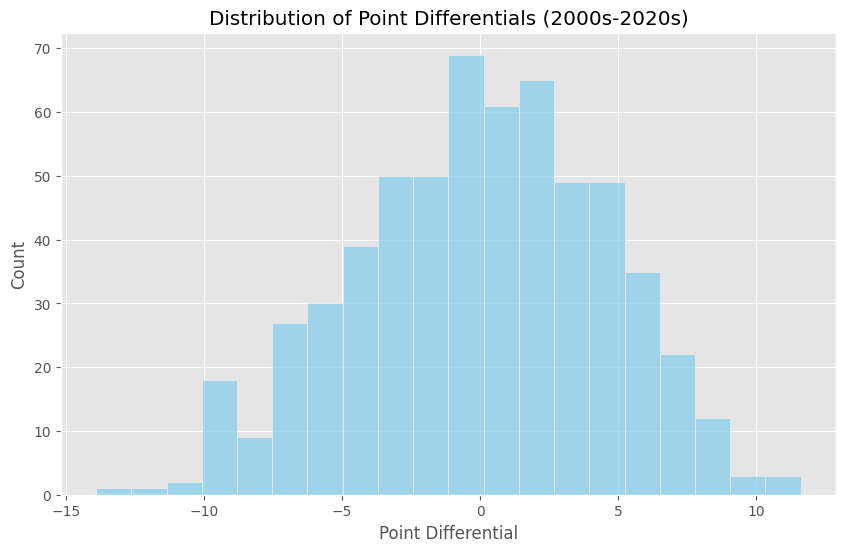

In [96]:
plt.figure(figsize=(10, 6))
sns.histplot(data=era_00_20, x='point_diff', bins=20, color='skyblue')
plt.title('Distribution of Point Differentials (2000s-2020s)')
plt.xlabel('Point Differential')
plt.ylabel('Count')

### 2020s to Present

In [34]:
# calculate skew
skew_value = era_20_26['point_diff'].skew()
print(f"Skewness of Point Differential: {skew_value}")

Skewness of Point Differential: -0.2948112254532661


Text(0, 0.5, 'Count')

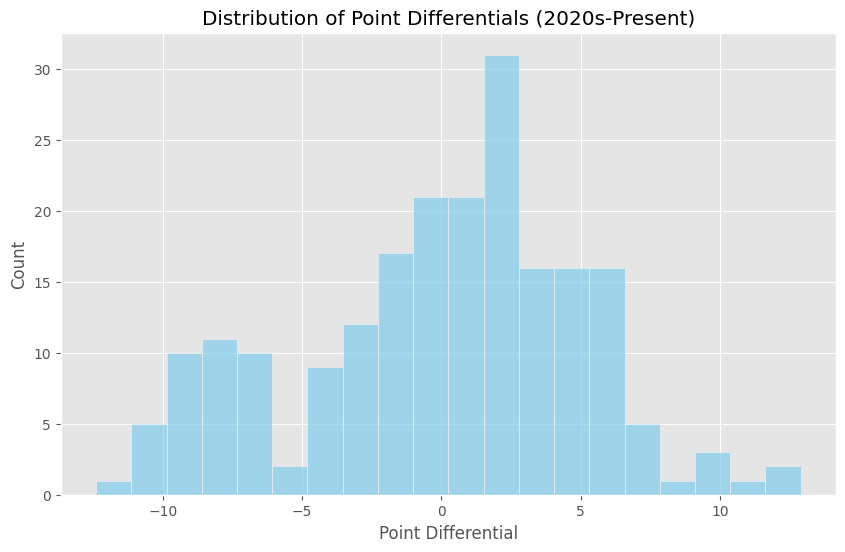

In [35]:
plt.figure(figsize=(10, 6))
sns.histplot(data=era_20_26, x='point_diff', bins=20, color='skyblue')
plt.title('Distribution of Point Differentials (2020s-Present)')
plt.xlabel('Point Differential')
plt.ylabel('Count')

## Correlation Matrix
For 1980-2000, these features are the strongest predictors of point_diff: fg_percent, x2p_percent, opp_x2p_percent, opp_drb_per_game\
For 2000-2020: fg_percent, opp_fg_percent\
For 2020-Present: x3p_percent, pts_per_game, fg_percent, x2p_percent, fg_per_game, opp_blk_per_game, opp_fg_per_game, opp_pts_per_game, opp_x2p_percent, opp_fg_percent

This shows the shift in strategy over the years. In the modern era, teams have shifted towards focusing on 3-pointers, whereas in the past field goals were the focus. This presents a potential conflict when splitting the dataset temporally.

There are more features that are stronger predictors (above 0.5 or below -0.5) for the 2020s-Present era than any other era. This is most likely because this era has a more uniform strategy (since it is a smaller subset of the overall data), thus more predictable. The other eras (1980-2000 and 2000-2020) have less strong predictors since they encompass larger timelines, and thus more strategy shifts over the period.

For feature selection, it is important we select features that are unique to each other to prevent multicollinearity. We can use this heatmap to prevent choosing redundant features.

### 1980s to 2000s

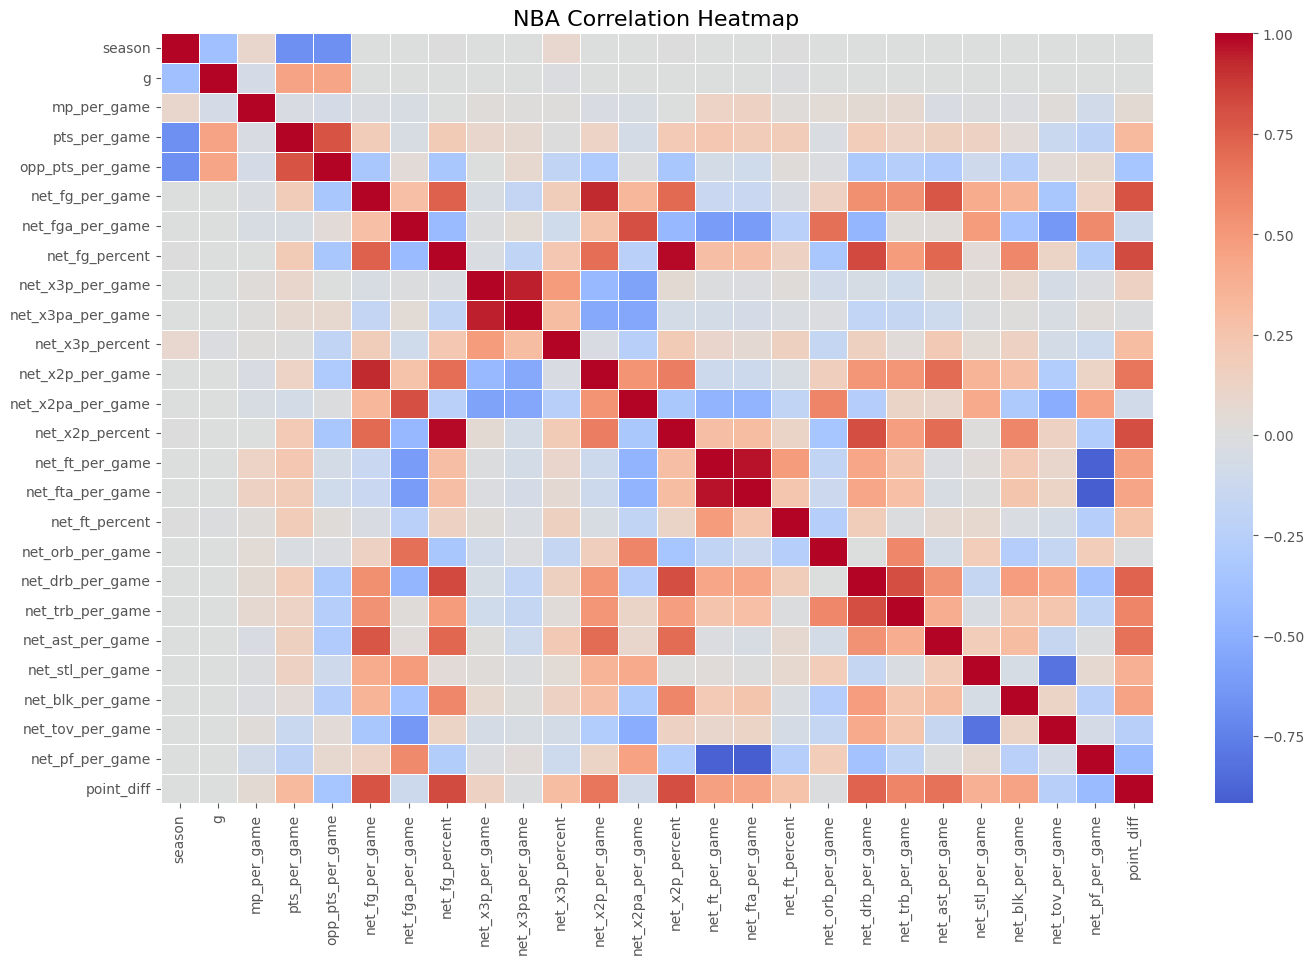

In [97]:
numeric_df = era_80_00.select_dtypes(include=['number'])
corr_matrix_80to00 = numeric_df.corr()
plt.figure(figsize=(16, 10))
sns.heatmap(corr_matrix_80to00, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('NBA Correlation Heatmap', fontsize=16)
plt.show()

In [98]:
target_corr = corr_matrix_80to00['point_diff'].sort_values(ascending=False)
print("Numerical Correlation")
print(target_corr)

Numerical Correlation
point_diff           1.000000
net_fg_percent       0.826953
net_x2p_percent      0.816059
net_fg_per_game      0.787823
net_drb_per_game     0.730589
net_ast_per_game     0.676886
net_x2p_per_game     0.656391
net_trb_per_game     0.596522
net_ft_per_game      0.467341
net_blk_per_game     0.450589
net_fta_per_game     0.443543
net_stl_per_game     0.373996
pts_per_game         0.316675
net_x3p_percent      0.300433
net_ft_percent       0.259043
net_x3p_per_game     0.140454
mp_per_game          0.050614
season              -0.000079
g                   -0.000147
net_orb_per_game    -0.004055
net_x3pa_per_game   -0.015406
net_x2pa_per_game   -0.090411
net_fga_per_game    -0.118326
net_tov_per_game    -0.258215
opp_pts_per_game    -0.341827
net_pf_per_game     -0.426853
Name: point_diff, dtype: float64


### 2000s to 2020s

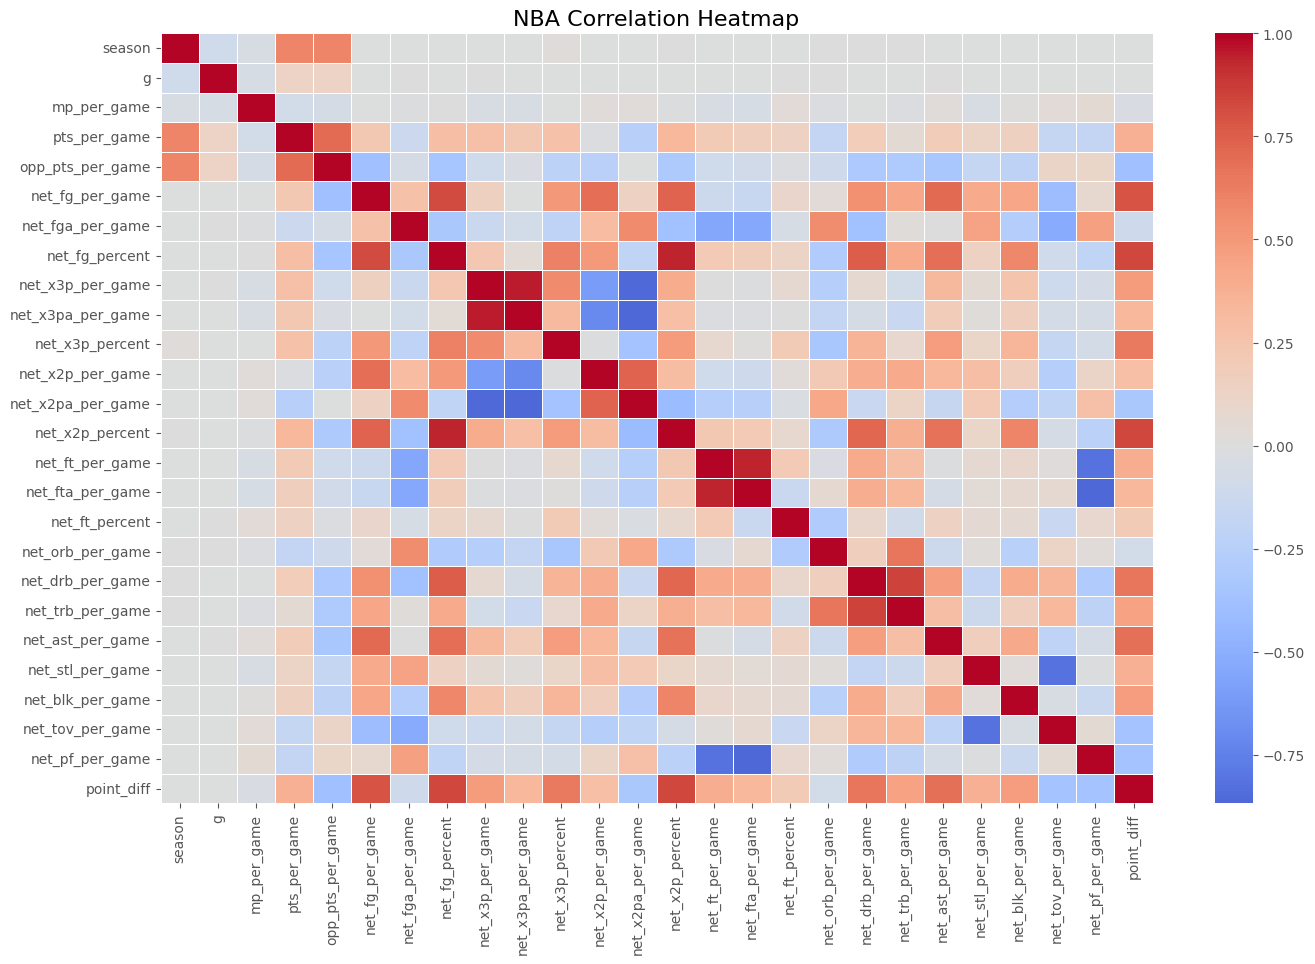

In [99]:
numeric_df = era_00_20.select_dtypes(include=['number'])
corr_matrix_00to20 = numeric_df.corr()
plt.figure(figsize=(16, 10))
sns.heatmap(corr_matrix_00to20, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('NBA Correlation Heatmap', fontsize=16)
plt.show()

In [100]:
target_corr = corr_matrix_00to20['point_diff'].sort_values(ascending=False)
print("Numerical Correlation")
print(target_corr)

Numerical Correlation
point_diff           1.000000
net_fg_percent       0.839176
net_x2p_percent      0.838270
net_fg_per_game      0.794837
net_ast_per_game     0.679138
net_drb_per_game     0.658310
net_x3p_percent      0.638356
net_x3p_per_game     0.487923
net_blk_per_game     0.481511
net_trb_per_game     0.456514
net_ft_per_game      0.391644
pts_per_game         0.379708
net_stl_per_game     0.375043
net_x3pa_per_game    0.332153
net_fta_per_game     0.330208
net_x2p_per_game     0.284573
net_ft_percent       0.202785
g                   -0.000319
season              -0.000368
mp_per_game         -0.033703
net_orb_per_game    -0.081903
net_fga_per_game    -0.102211
net_x2pa_per_game   -0.324919
net_tov_per_game    -0.362896
net_pf_per_game     -0.363380
opp_pts_per_game    -0.384647
Name: point_diff, dtype: float64


### 2020s to Present

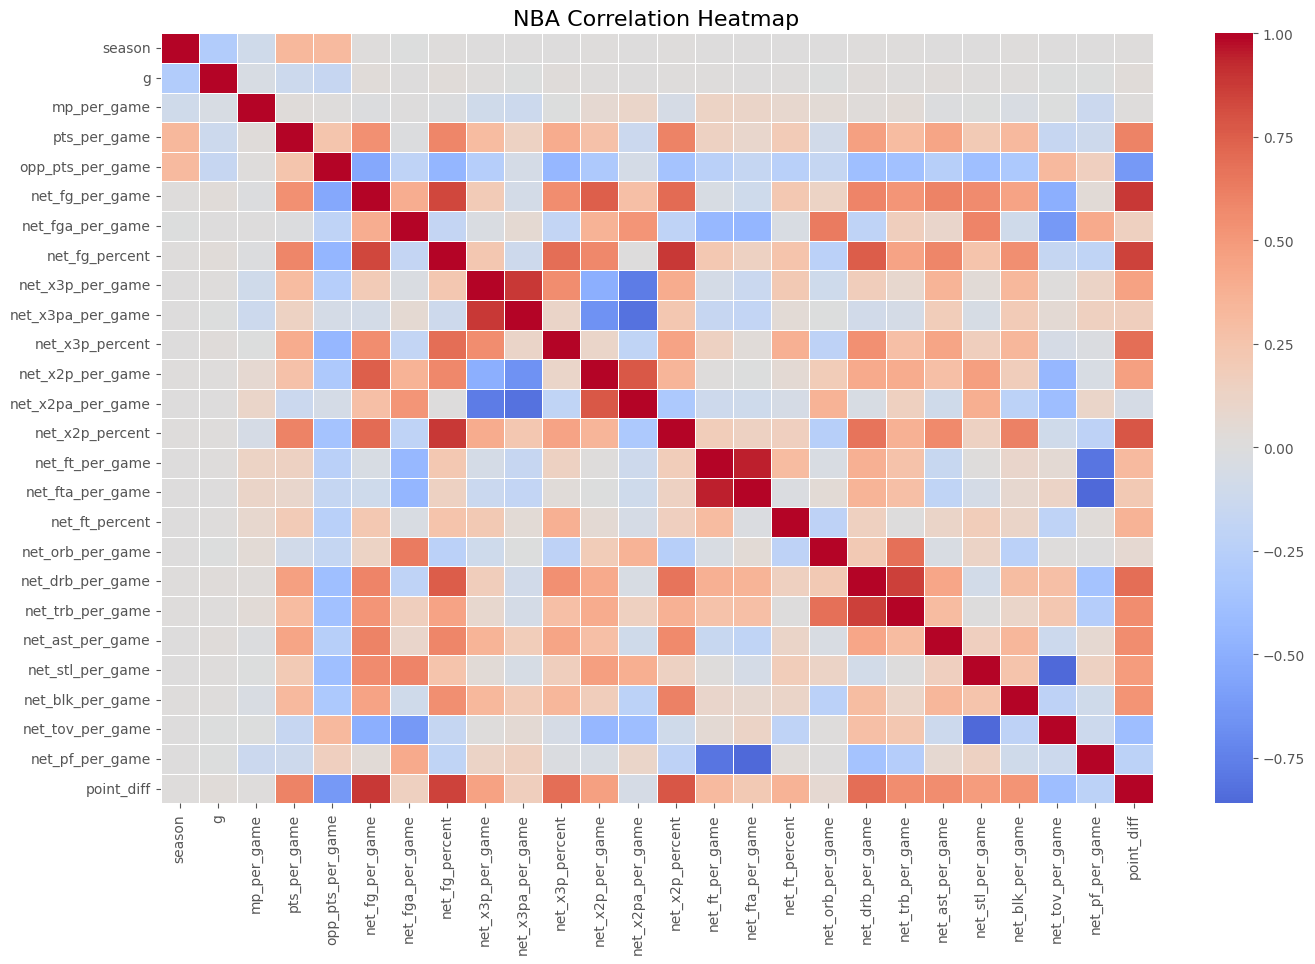

In [101]:
numeric_df = era_20_26.select_dtypes(include=['number'])
corr_matrix_20toPresent = numeric_df.corr()
plt.figure(figsize=(16, 10))
sns.heatmap(corr_matrix_20toPresent, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('NBA Correlation Heatmap', fontsize=16)
plt.show()

In [102]:
target_corr = corr_matrix_20toPresent['point_diff'].sort_values(ascending=False)
print("Numerical Correlation")
print(target_corr)

Numerical Correlation
point_diff           1.000000
net_fg_per_game      0.882923
net_fg_percent       0.851714
net_x2p_percent      0.785530
net_drb_per_game     0.693922
net_x3p_percent      0.692306
pts_per_game         0.605294
net_ast_per_game     0.561485
net_trb_per_game     0.552999
net_blk_per_game     0.520568
net_stl_per_game     0.485684
net_x2p_per_game     0.464952
net_x3p_per_game     0.461973
net_ft_percent       0.362731
net_ft_per_game      0.312411
net_fta_per_game     0.210787
net_x3pa_per_game    0.165715
net_fga_per_game     0.153576
net_orb_per_game     0.065696
g                    0.028693
season               0.007203
mp_per_game          0.007045
net_x2pa_per_game   -0.053823
net_pf_per_game     -0.226150
net_tov_per_game    -0.396525
opp_pts_per_game    -0.622385
Name: point_diff, dtype: float64


## Skew for All Features
Depending on the ML model we choose, we may have to transform certain features (those with a skew >1 or <-1)

### 1980s to 2000s

In [103]:
skewness_series = era_80_00.select_dtypes(include=['number']).skew().sort_values(ascending=False)

print("Features Skews:")
print(skewness_series)

Features Skews:
mp_per_game          0.648560
net_x3pa_per_game    0.304002
net_fga_per_game     0.275776
net_stl_per_game     0.217514
net_x3p_per_game     0.107500
net_pf_per_game      0.104396
net_orb_per_game     0.047330
net_x2p_per_game     0.047161
net_x2p_percent     -0.020418
net_blk_per_game    -0.025577
net_drb_per_game    -0.064291
net_fg_percent      -0.072188
net_fg_per_game     -0.084794
net_ast_per_game    -0.116357
net_trb_per_game    -0.118826
season              -0.124458
net_ft_per_game     -0.182019
net_fta_per_game    -0.186877
net_x2pa_per_game   -0.204019
pts_per_game        -0.208938
net_tov_per_game    -0.214661
net_ft_percent      -0.231165
point_diff          -0.245927
opp_pts_per_game    -0.291438
net_x3p_percent     -0.359123
g                   -3.833891
dtype: float64


### 2000s to 2020s

In [104]:
skewness_series = era_00_20.select_dtypes(include=['number']).skew().sort_values(ascending=False)

print("Features Skews:")
print(skewness_series)

Features Skews:
mp_per_game          0.673711
pts_per_game         0.491953
net_ast_per_game     0.333357
net_x3p_per_game     0.322546
opp_pts_per_game     0.314331
net_x3pa_per_game    0.272638
net_x2p_percent      0.201689
net_fta_per_game     0.197544
net_blk_per_game     0.195481
net_ft_per_game      0.132279
net_fg_percent       0.118134
net_drb_per_game     0.057081
net_tov_per_game     0.051419
net_stl_per_game     0.007542
net_x3p_percent     -0.009905
season              -0.012266
net_fga_per_game    -0.052919
net_fg_per_game     -0.172381
point_diff          -0.177997
net_orb_per_game    -0.179286
net_x2p_per_game    -0.183804
net_pf_per_game     -0.195385
net_trb_per_game    -0.202356
net_x2pa_per_game   -0.316128
net_ft_percent      -0.325012
g                   -4.117903
dtype: float64


### 2020s to Present

In [105]:
skewness_series = era_20_26.select_dtypes(include=['number']).skew().sort_values(ascending=False)

print("Features Skews:")
print(skewness_series)

Features Skews:
mp_per_game          0.633319
net_x3pa_per_game    0.408028
net_fga_per_game     0.374552
net_x3p_per_game     0.373071
net_orb_per_game     0.284577
net_stl_per_game     0.216259
opp_pts_per_game     0.203073
net_trb_per_game     0.203064
net_x2p_percent      0.173764
net_x2p_per_game     0.127974
net_ast_per_game     0.079804
net_pf_per_game      0.066099
net_fg_per_game      0.057449
season               0.000000
net_drb_per_game    -0.002526
net_ft_percent      -0.003773
net_blk_per_game    -0.007890
net_ft_per_game     -0.077606
net_fta_per_game    -0.078125
net_x3p_percent     -0.080505
net_fg_percent      -0.085657
net_tov_per_game    -0.168080
net_x2pa_per_game   -0.251290
pts_per_game        -0.272987
point_diff          -0.294811
g                   -1.425283
dtype: float64


## Outliers
Which features we choose will impact how we deal with outliers. If we choose a feature with few outliers, we may keep the outliers since they are insignificant. But if there are more outliers then we may transform or Winsorize the data.

### 1980s to 2000s

In [106]:
numeric_cols = era_80_00.select_dtypes(include=['number'])

Q1 = numeric_cols.quantile(0.25)
Q3 = numeric_cols.quantile(0.75)
IQR = Q3 - Q1

minim = Q1 - 1.5 * IQR
maxim = Q3 + 1.5 * IQR

outliers = (numeric_cols < minim) | (numeric_cols > maxim)

outlier_counts = outliers.sum().sort_values(ascending=False)
print("Features with the most outliers:")
print(outlier_counts[outlier_counts > 0])

Features with the most outliers:
net_x3pa_per_game    30
g                    29
net_x3p_per_game     19
opp_pts_per_game     11
net_tov_per_game     11
net_x3p_percent       9
mp_per_game           9
net_stl_per_game      7
net_ft_per_game       6
net_x2p_per_game      5
net_x2pa_per_game     5
net_ft_percent        4
net_pf_per_game       4
net_fga_per_game      4
net_fta_per_game      4
net_orb_per_game      3
net_ast_per_game      2
pts_per_game          2
net_blk_per_game      1
net_trb_per_game      1
point_diff            1
dtype: int64


### 2000s to 2020s

In [107]:
numeric_cols = era_00_20.select_dtypes(include=['number'])

Q1 = numeric_cols.quantile(0.25)
Q3 = numeric_cols.quantile(0.75)
IQR = Q3 - Q1

minim = Q1 - 1.5 * IQR
maxim = Q3 + 1.5 * IQR

outliers = (numeric_cols < minim) | (numeric_cols > maxim)

outlier_counts = outliers.sum().sort_values(ascending=False)
print("Features with the most outliers:")
print(outlier_counts[outlier_counts > 0])

Features with the most outliers:
g                    32
net_ast_per_game     10
pts_per_game          9
net_blk_per_game      8
mp_per_game           8
net_pf_per_game       8
net_orb_per_game      7
net_ft_percent        7
net_stl_per_game      6
net_fta_per_game      6
net_x3p_percent       6
net_x2pa_per_game     5
net_x2p_per_game      5
net_x3pa_per_game     5
net_fg_percent        5
net_fga_per_game      5
opp_pts_per_game      5
net_x3p_per_game      4
net_trb_per_game      4
net_x2p_percent       4
net_fg_per_game       3
net_ft_per_game       2
net_drb_per_game      2
point_diff            1
net_tov_per_game      1
dtype: int64


### 2020s to Present

In [108]:
numeric_cols = era_20_26.select_dtypes(include=['number'])

Q1 = numeric_cols.quantile(0.25)
Q3 = numeric_cols.quantile(0.75)
IQR = Q3 - Q1

minim = Q1 - 1.5 * IQR
maxim = Q3 + 1.5 * IQR

outliers = (numeric_cols < minim) | (numeric_cols > maxim)

outlier_counts = outliers.sum().sort_values(ascending=False)
print("Features with the most outliers:")
print(outlier_counts[outlier_counts > 0])

Features with the most outliers:
g                    30
net_orb_per_game      5
net_x3p_per_game      4
net_tov_per_game      4
net_blk_per_game      4
net_x2p_percent       3
net_stl_per_game      3
net_x3pa_per_game     3
point_diff            3
net_fg_per_game       2
net_x2p_per_game      2
net_x2pa_per_game     2
net_fga_per_game      2
net_pf_per_game       2
net_trb_per_game      2
net_ast_per_game      1
mp_per_game           1
net_ft_percent        1
opp_pts_per_game      1
dtype: int64


# Feature Selection

As discussed in [Walsh and Joshi](https://www.sciencedirect.com/science/article/pii/S266682702400015X) and also mentioned above, we need to select features in a way that avoids multicolinearity.

The following shows which features have a correlation |r| > 0.7 with each other, indicating a risk of multicolinearity.

In [110]:
#Code from Stack Overflow https://stackoverflow.com/questions/34902649/how-do-i-loop-across-a-correlation-matrix-to-only-give-me-pairs-of-correlations

numeric_df = NBA_merged_df.select_dtypes(include=['number'])
corr_matrix_merged = numeric_df.corr()

rows, cols = corr_matrix_00to20.shape
flds = list(corr_matrix_00to20.columns)

corr = corr_matrix_00to20.to_numpy()

#These are our dependent variables, ignore them for feature selection.
ppg_index = flds.index("pts_per_game")
opp_ppg_index = flds.index("opp_pts_per_game")

for i in range(cols):
    if(i == ppg_index or i == opp_ppg_index): continue
    for j in range(i+1, cols):
        if(j == ppg_index  or j == opp_ppg_index): continue
        if corr[i,j] > 0.7 or corr[i,j] < -0.7:
            print(flds[i], ' ', flds[j], ' ', corr[i,j])

net_fg_per_game   net_fg_percent   0.8234891051417832
net_fg_per_game   net_x2p_percent   0.7355779334104389
net_fg_per_game   net_ast_per_game   0.7111928199649233
net_fg_per_game   point_diff   0.794837111762476
net_fg_percent   net_x2p_percent   0.9400346740383217
net_fg_percent   net_drb_per_game   0.7554013716554457
net_fg_percent   point_diff   0.8391757688984489
net_x3p_per_game   net_x3pa_per_game   0.9556359885288818
net_x3p_per_game   net_x2pa_per_game   -0.8573129018315493
net_x3pa_per_game   net_x2p_per_game   -0.7019845835845279
net_x3pa_per_game   net_x2pa_per_game   -0.8675821893015863
net_x2p_per_game   net_x2pa_per_game   0.7364934947703405
net_x2p_percent   net_drb_per_game   0.7194692461686004
net_x2p_percent   point_diff   0.8382695763446628
net_ft_per_game   net_fta_per_game   0.9386241683414597
net_ft_per_game   net_pf_per_game   -0.8226503497316201
net_fta_per_game   net_pf_per_game   -0.8681497545948416
net_drb_per_game   net_trb_per_game   0.8472084949068487
ne

Then, we can use the Featurewiz package's SULOV in order to pick only the most

In [111]:
!pip install featurewiz

############################################################################################
############       F A S T   F E A T U R E  E N G G    A N D    S E L E C T I O N ! ########
# Be judicious with featurewiz. Don't use it to create too many un-interpretable features! #
############################################################################################
featurewiz has selected 0.7 as the correlation limit. Change this limit to fit your needs...
    Skipping feature engineering since no feature_engg input...
Skipping category encoding since no category encoders specified in input...
    Single_Label Regression problem 
    Loaded train data. Shape = (1314, 30)
    Single_Label Regression problem 
No test data filename given...
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
########################################################################

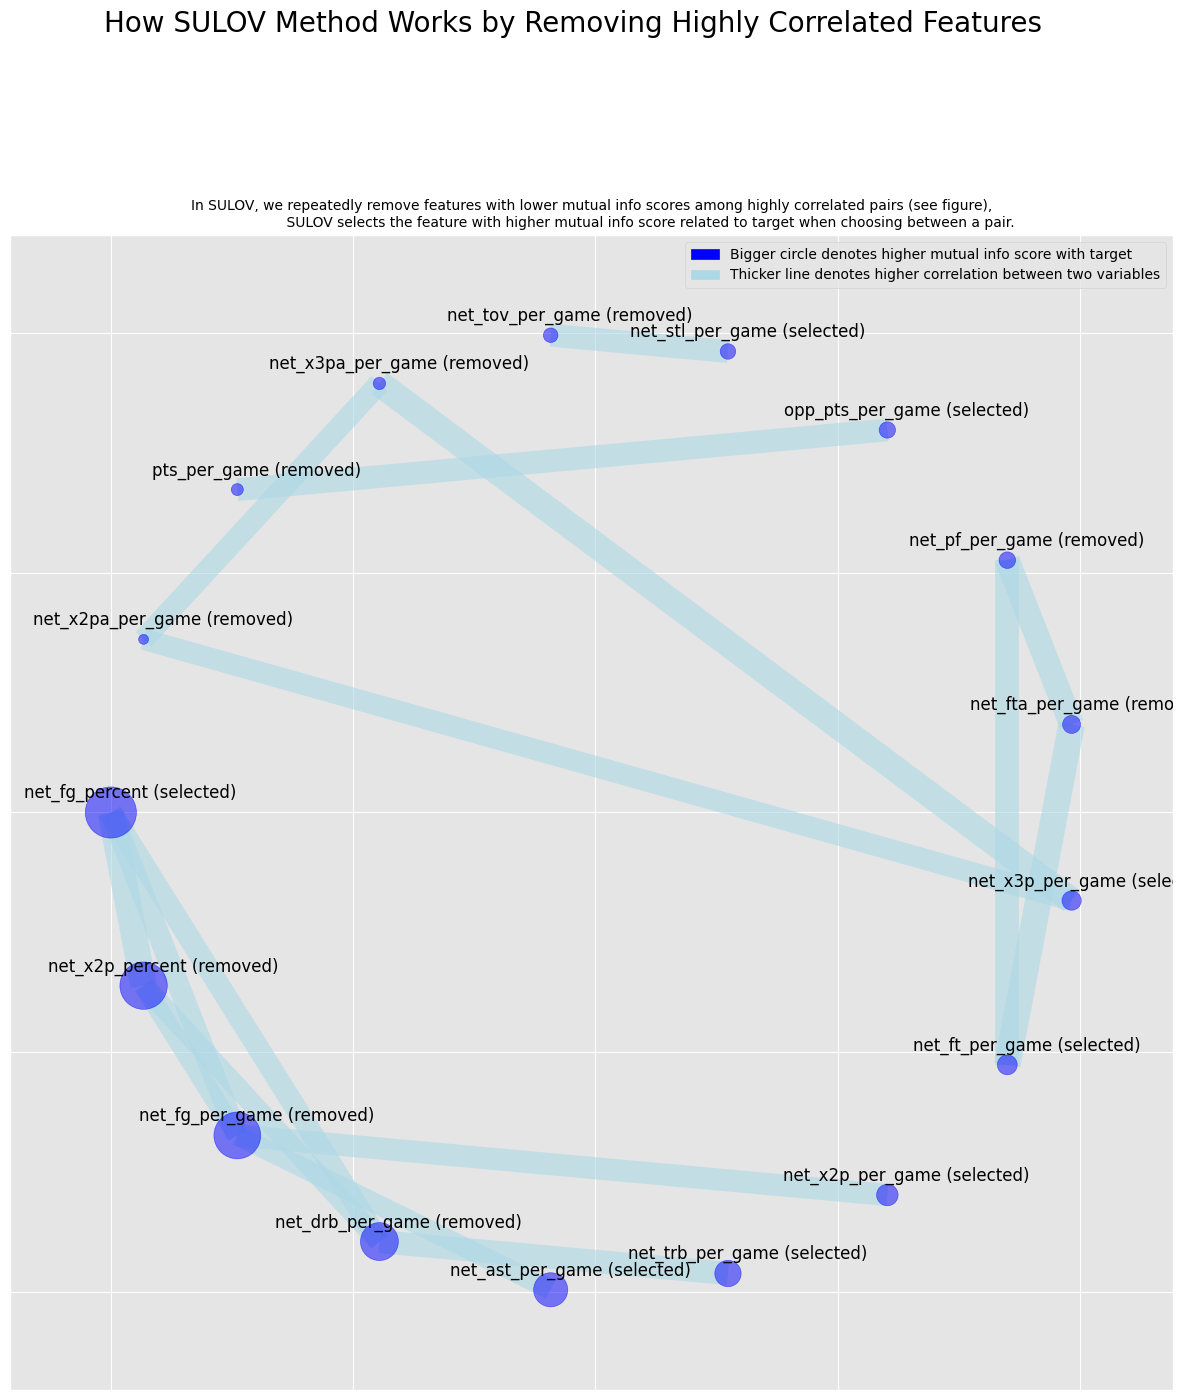

Time taken for SULOV method = 1 seconds
    Adding 3 categorical variables to reduced numeric variables  of 15
Final list of selected 18 vars after SULOV = ['g', 'mp_per_game', 'net_fga_per_game', 'net_x3p_percent', 'net_ft_percent', 'net_orb_per_game', 'net_blk_per_game', 'net_fg_percent', 'net_ast_per_game', 'net_trb_per_game', 'net_x2p_per_game', 'net_ft_per_game', 'net_x3p_per_game', 'opp_pts_per_game', 'net_stl_per_game', 'team', 'abbreviation', 'playoffs']
Converting all features to numeric before sending to XGBoost...
    there were no mixed data types or object columns that errored. Data is all numeric...
Shape of train data after adding missing values flags = (1314, 19)
Skipping Recursive XGBoost method. Continuing ...
#######################################################################################
#####          F E A T U R E   S E L E C T I O N   C O M P L E T E D            #######
######################################################################################

In [120]:
import featurewiz as fwiz

outputs = fwiz.featurewiz(dataname=NBA_merged_df, target="point_diff", corr_limit=0.70, verbose=2, sep=',',
		header=0, test_data='',feature_engg='', category_encoders='',
		dask_xgboost_flag=False, nrows=None, skip_sulov=False, skip_xgboost=True)